# NEO Silver - EDA & Gold Layer Design

**Dataset:** 5 years of NASA Near Earth Object close approaches (2021-2026)  
**Source:** `storage/silver/neo/`  
**Goal:** Understand the data signals before designing the gold enrichment layer.

This notebook explores what separates hazardous from non-hazardous objects,
what the sentry flag actually measures, which fields are redundant, and what
a meaningful risk score should look like. The enrichment logic built here
moves to `gold/neo/enrich.py` once validated.

## Table of contents

1. [Load data](#1-load-data)

2. [Sanity check](#2-sanity-check)

3. [Descriptive statistics](#3-descriptive-statistics)

4. [Hazardous vs non-hazardous](#4-hazardous-vs-non-hazardous)

5. [Sentry vs non-sentry](#5-sentry-vs-non-sentry)

6. [Visualizations](#6-visualizations)

7. [Key insights](#7-key-insights)

8. [Gold layer design](#8-gold-layer-design)

9. [Final gold dataset](#9-final-gold-dataset)

10. [Summary](#10-summary)

## 1. Load data <a id="1-load-data"></a>

In [34]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet(sorted(Path('../../storage/silver/neo').glob('neo_*.parquet'))[-1])
print(f"Loaded {len(df)} rows")
df.dtypes

Loaded 10133 rows


hash_id                             object
id                                  object
name                                object
date                        datetime64[ns]
nasa_jpl_url                        object
absolute_magnitude_h               float64
diameter_km_min                    float64
diameter_km_max                    float64
is_potentially_hazardous              bool
is_sentry_object                      bool
close_approach_date         datetime64[ns]
close_approach_datetime     datetime64[ns]
velocity_km_per_s                  float64
miss_distance_au                   float64
miss_distance_lunar                float64
miss_distance_km                   float64
diameter_km_avg                    float64
dtype: object

## 2. Sanity check <a id="2-sanity-check"></a>

Checking for nulls, duplicates, and correct data types before any analysis.

In [35]:
print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicates:", df["hash_id"].duplicated().sum())
print("\nTypes:\n", df.dtypes)

Shape: (10133, 17)

Nulls:
 hash_id                     0
id                          0
name                        0
date                        0
nasa_jpl_url                0
absolute_magnitude_h        0
diameter_km_min             0
diameter_km_max             0
is_potentially_hazardous    0
is_sentry_object            0
close_approach_date         0
close_approach_datetime     0
velocity_km_per_s           0
miss_distance_au            0
miss_distance_lunar         0
miss_distance_km            0
diameter_km_avg             0
dtype: int64

Duplicates: 0

Types:
 hash_id                             object
id                                  object
name                                object
date                        datetime64[ns]
nasa_jpl_url                        object
absolute_magnitude_h               float64
diameter_km_min                    float64
diameter_km_max                    float64
is_potentially_hazardous              bool
is_sentry_object                      

## 3. Descriptive statistics <a id="3-descriptive-statistics"></a>

Summary stats across all numeric fields: ranges, means, and distributions.

In [36]:
df.describe()

,absolute_magnitude_h,diameter_km_min,diameter_km_max,velocity_km_per_s,miss_distance_au,miss_distance_lunar,miss_distance_km,diameter_km_avg
count,10133.000000,10133.000000,10133.000000,10133.000000,10133.000000,10133.000000,1.013300e+04,10133.000000
mean,23.566993,0.114392,0.255788,13.965780,0.273142,106.252044,4.086139e+07,0.185090
std,2.778809,0.285001,0.637281,7.027428,0.137249,53.389825,2.053214e+07,0.461141
min,10.390000,0.000818,0.001828,0.256356,0.000913,0.355229,1.366105e+05,0.001323
25%,21.410000,0.019704,0.044060,8.515152,0.157401,61.229041,2.354687e+07,0.031882
50%,23.700000,0.048368,0.108153,13.129758,0.278543,108.353217,4.166944e+07,0.078260
75%,25.650000,0.138853,0.310485,18.287702,0.392674,152.750122,5.874317e+07,0.224669
max,32.560000,22.210328,49.663804,51.704413,0.499952,194.481163,7.479169e+07,35.937066


## 4. Hazardous vs non-hazardous <a id="4-hazardous-vs-non-hazardous"></a>

Comparing average size, velocity, and distance between hazardous and 
non-hazardous objects. What actually separates the two groups?

In [37]:
cols = ["absolute_magnitude_h", "diameter_km_avg", "miss_distance_lunar", "velocity_km_per_s"]
df.groupby("is_potentially_hazardous")[cols].mean().round(3).T

is_potentially_hazardous,False,True
absolute_magnitude_h,23.949,20.445
diameter_km_avg,0.156,0.420
miss_distance_lunar,108.355,89.053
velocity_km_per_s,13.520,17.615


| | Not hazardous | Hazardous |
|---|---|---|
| Magnitude | 23.9 | 20.4 |
| Diameter avg | 0.156 km | 0.420 km |
| Miss distance | 108 LD | 89 LD |
| Velocity | 13.5 km/s | 17.6 km/s |

Hazardous objects are on average 3x larger, pass 17% closer, and travel 30% 
faster than non-hazardous ones. This aligns with NASA's definition — an object 
is potentially hazardous if its diameter exceeds 140 meters AND its orbit brings 
it within 0.05 AU of Earth's orbit. Size and proximity are the primary drivers.

The lower magnitude score for hazardous objects (20.4 vs 23.9) confirms the 
size signal — lower magnitude means intrinsically brighter, which means larger.

## 5. Sentry vs non-sentry <a id="5-sentry-vs-non-sentry"></a>

Comparing the sentry flag across size, velocity, and distance. Sentry objects 
look completely different from hazardous ones — smaller, slower, and not 
necessarily closer. Also includes the slowest objects in the dataset, which 
are slow for the same reason sentry objects are small: unusual orbital 
relationships with Earth.

In [38]:
print("Hazardous:\n", df["is_potentially_hazardous"].value_counts())
print("\nSentry:\n", df["is_sentry_object"].value_counts())
print("\nBoth:\n", df.groupby(["is_potentially_hazardous", "is_sentry_object"]).size())

Hazardous:
 False    9029
True     1104
Name: is_potentially_hazardous, dtype: int64

Sentry:
 False    9655
True      478
Name: is_sentry_object, dtype: int64

Both:
 is_potentially_hazardous  is_sentry_object
False                     False               8551
                          True                 478
True                      False               1104
dtype: int64


In [39]:
df.groupby("is_sentry_object")[cols].mean().round(3).T

is_sentry_object,False,True
absolute_magnitude_h,23.370,27.551
diameter_km_avg,0.193,0.017
miss_distance_lunar,106.183,107.639
velocity_km_per_s,14.040,12.464


In [58]:
# slowest objects - co-orbiting with Earth
df.nsmallest(3, "velocity_km_per_s")[
    ["name", "date", "velocity_km_per_s", "miss_distance_lunar", 
     "is_potentially_hazardous", "is_sentry_object"]
]

,name,date,velocity_km_per_s,miss_distance_lunar,is_potentially_hazardous,is_sentry_object
9247,(2025 US6),2025-11-22,0.256356,0.993887,False,False
5891,(2018 BW5),2024-01-08,0.530438,144.102980,False,False
3284,(2017 UF52),2022-11-15,0.536816,124.726187,False,False


In [41]:
# largest sentry objects — how close to the hazardous threshold?
df[df["is_sentry_object"] == True].nlargest(5, "diameter_km_avg")[
    ["name", "diameter_km_avg", "miss_distance_lunar", "is_potentially_hazardous"]
]

,name,diameter_km_avg,miss_distance_lunar,is_potentially_hazardous
1025,(2016 WG),0.098524,118.305437,False
3666,(2019 UC14),0.092799,112.327453,False
6064,(2008 UB7),0.081949,187.689166,False
5173,(2008 EX5),0.074738,106.211527,False
3461,(2015 FN36),0.069750,176.017391,False


| | Not sentry | Sentry |
|---|---|---|
| Magnitude | 23.4 | 27.6 |
| Diameter avg | 0.193 km | 0.017 km |
| Miss distance | 106 LD | 108 LD |
| Velocity | 14.0 km/s | 12.5 km/s |

Sentry objects are on average 11x smaller than non-sentry objects and pass at 
nearly identical distances. They are flagged because NASA's Sentry system 
calculated a non-zero probability of Earth impact based on orbital trajectory 
alone — not size or proximity.

The slowest objects in the dataset move under 0.6 km/s — far below the 14 km/s 
average. These are co-orbiting with Earth, drifting past slowly the way two cars 
on a highway moving at similar speeds pass each other gradually.

The largest sentry object is 99 meters,41 meters below NASA's 140 meter 
hazardous threshold. The size gap between the two populations is structural.

## 6. Visualizations <a id="6-visualizations"></a>

Boxplots, correlation matrix, and scatter plots to see the distributions
and relationships visually before making gold layer decisions.

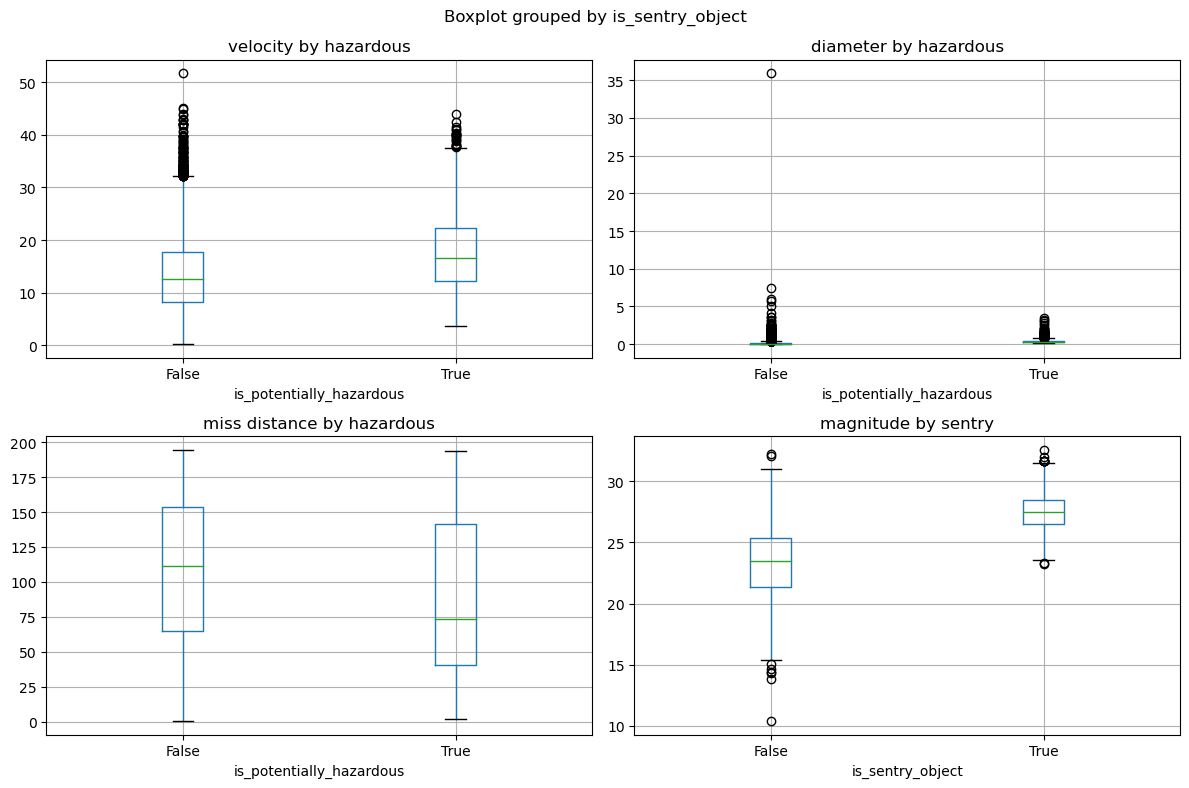

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.boxplot(column="velocity_km_per_s", by="is_potentially_hazardous", ax=axes[0,0])
axes[0,0].set_title("velocity by hazardous")

df.boxplot(column="diameter_km_avg", by="is_potentially_hazardous", ax=axes[0,1])
axes[0,1].set_title("diameter by hazardous")

df.boxplot(column="miss_distance_lunar", by="is_potentially_hazardous", ax=axes[1,0])
axes[1,0].set_title("miss distance by hazardous")

df.boxplot(column="absolute_magnitude_h", by="is_sentry_object", ax=axes[1,1])
axes[1,1].set_title("magnitude by sentry")

plt.tight_layout()
plt.show()

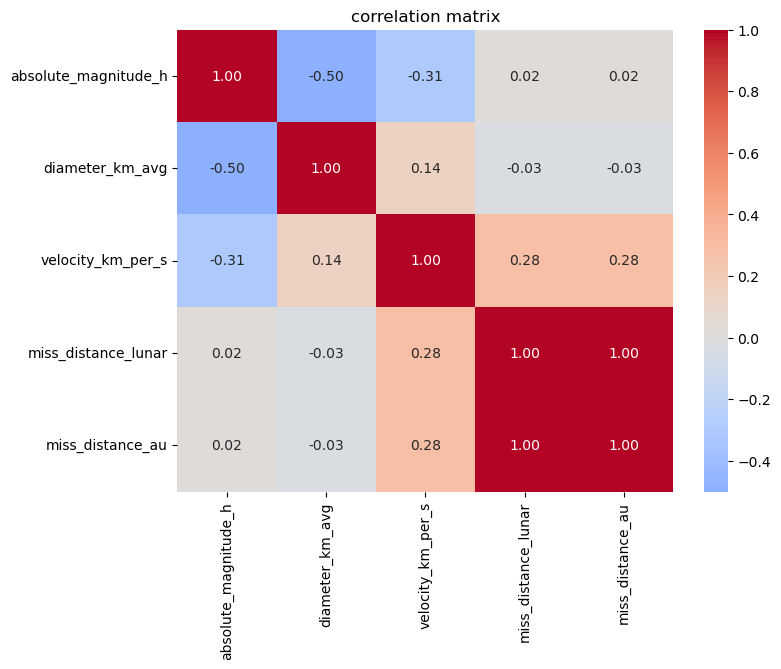

In [43]:
corr_cols = ["absolute_magnitude_h", "diameter_km_avg", "velocity_km_per_s",
             "miss_distance_lunar", "miss_distance_au"]

corr = df[corr_cols].corr().round(2)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("correlation matrix")
plt.show()

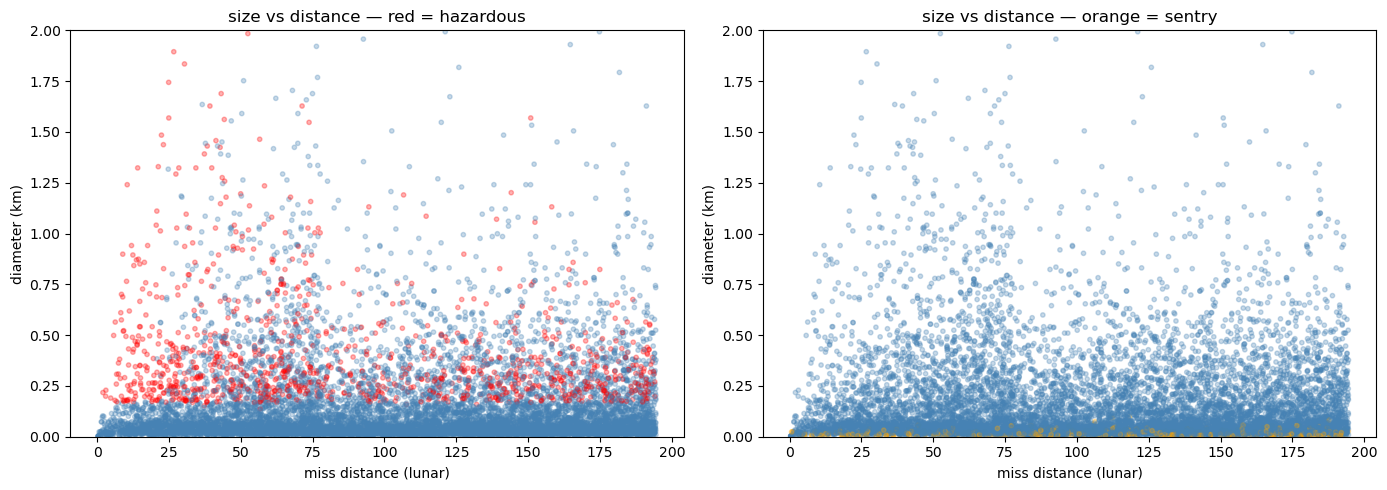

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_h = df["is_potentially_hazardous"].map({True: "red", False: "steelblue"})
axes[0].scatter(df["miss_distance_lunar"], df["diameter_km_avg"],
                c=colors_h, alpha=0.3, s=10)
axes[0].set_xlabel("miss distance (lunar)")
axes[0].set_ylabel("diameter (km)")
axes[0].set_title("size vs distance — red = hazardous")
axes[0].set_ylim(0, 2)

colors_s = df["is_sentry_object"].map({True: "orange", False: "steelblue"})
axes[1].scatter(df["miss_distance_lunar"], df["diameter_km_avg"],
                c=colors_s, alpha=0.3, s=10)
axes[1].set_xlabel("miss distance (lunar)")
axes[1].set_ylabel("diameter (km)")
axes[1].set_title("size vs distance — orange = sentry")
axes[1].set_ylim(0, 2)

plt.tight_layout()
plt.show()

**Boxplots**

Velocity by hazardous: hazardous objects have a higher median (16 km/s vs 
11 km/s) but the distributions overlap heavily. Velocity alone is not a 
clean separator.

Diameter by hazardous: both groups cluster near zero with extreme outliers. 
The boxes look similar because most asteroids are small regardless of hazard flag.

Miss distance by hazardous: hazardous objects pass closer on average (72 LD 
vs 110 LD) but with massive spread. Distance matters but is not clean on its own.

Magnitude by sentry: the cleanest separation of all four plots. Sentry objects 
cluster tightly at magnitude 27-29, consistently small and faint.

**Correlation matrix**

| Pair | Correlation | Meaning |
|---|---|---|
| magnitude / diameter | -0.50 | bigger = brighter = lower magnitude |
| magnitude / velocity | -0.31 | faster objects tend to be larger |
| velocity / miss distance | 0.28 | weak positive relationship |
| miss_lunar / miss_au | 1.00 | perfectly redundant, same measurement |

**Scatter plots**

Hazardous: red dots cluster in the upper left corner, large diameter combined 
with close approach. The hazardous flag is essentially drawing a boundary in 
size and distance space.

Sentry: orange dots hug the bottom across all distances. Tiny objects spread 
everywhere regardless of how far they passed. Sentry is purely a trajectory 
signal, not a size or proximity signal.

## 7. Key insights <a id="7-key-insights"></a>

> **The two flags never overlap.** In 5 years of data, not a single object 
> carries both the hazardous and sentry flag simultaneously.

The two flags screen for fundamentally different risk profiles:

Hazardous  →  size + proximity  →  would cause massive damage IF it hit
Sentry     →  orbital math      →  has a non-zero chance of actually hitting

A city-killer asteroid passing at 44 lunar distances gets the hazardous flag.
A house-sized rock on a mathematically intersecting trajectory gets the sentry 
flag. Both represent real risk — just different kinds.

The physics that produces one tends to prevent the other. Large objects have 
uncertain long-range orbits making impact probability hard to confirm. Small 
objects have precise predictable orbits but fall below the hazardous size threshold.

**Gold layer implication:** a single risk score is insufficient. Hazard and 
sentry need to be treated as independent signals.

## 8. Gold layer design <a id="8-gold-layer-design"></a>

Building the enrichment logic directly in the notebook before moving it to 
`gold/neo/enrich.py`. Each function is tested here first.

In [46]:
# size classification
def classify_size(diameter_km):
    if diameter_km < 0.025:   return "tiny"
    elif diameter_km < 0.140: return "small"
    elif diameter_km < 1.0:   return "medium"
    elif diameter_km < 5.0:   return "large"
    else:                     return "major"

df["size_class"] = df["diameter_km_avg"].apply(classify_size)
df["size_class"].value_counts()

small     4478
medium    3491
tiny      1960
large      199
major        5
Name: size_class, dtype: int64

In [47]:
# named asteroid flag
def is_named(name):
    return not name.strip().startswith("(")

df["is_named"] = df["name"].apply(is_named)
df["is_named"].value_counts()

False    9031
True     1102
Name: is_named, dtype: int64

In [48]:
# hazard score — proximity + velocity + size
prox = 1 - (df["miss_distance_lunar"] / df["miss_distance_lunar"].max())
vel  = df["velocity_km_per_s"]         / df["velocity_km_per_s"].max()
size = df["diameter_km_avg"]           / df["diameter_km_avg"].max()

df["hazard_score"] = ((prox * 0.40) + (vel * 0.30) + (size * 0.30)).round(4)

# check score distribution by hazardous flag
df.groupby("is_potentially_hazardous")["hazard_score"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
is_potentially_hazardous,,,,,,,,
False,9029.0,0.257,0.104,0.016,0.175,0.252,0.339,0.586
True,1104.0,0.323,0.111,0.031,0.233,0.341,0.410,0.550


In [49]:
# hazard label thresholds based on score distribution
def hazard_label(score):
    if score >= 0.50:   return "critical"
    elif score >= 0.35: return "high"
    elif score >= 0.20: return "moderate"
    else:               return "low"

df["hazard_label"] = df["hazard_score"].apply(hazard_label)

print(df["hazard_label"].value_counts())
print()
print(df.groupby(["hazard_label", "is_potentially_hazardous"]).size().unstack(fill_value=0))

moderate    4458
low         3180
high        2443
critical      52
Name: hazard_label, dtype: int64

is_potentially_hazardous  False  True 
hazard_label                          
critical                     23     29
high                       1959    484
low                        2978    202
moderate                   4069    389


In [50]:
# why did we score some hazardous objects low?
df[(df["hazard_label"] == "low") & (df["is_potentially_hazardous"] == True)].nlargest(5, "miss_distance_lunar")[
    ["name", "diameter_km_avg", "miss_distance_lunar", "velocity_km_per_s", "hazard_score"]
]

,name,diameter_km_avg,miss_distance_lunar,velocity_km_per_s,hazard_score
7411,(2016 EJ56),0.198400,194.104164,31.715049,0.1864
3411,(2013 PV13),0.307286,193.776767,23.571000,0.1408
5624,480808 (1994 XL1),0.320289,193.610925,28.553755,0.1701
4989,101955 Bennu (1999 RQ36),0.390429,193.243774,19.968859,0.1217
2187,216258 (2006 WH1),0.369439,193.227286,25.530775,0.1538


In [51]:
# why did we score some non-hazardous objects critical?
df[(df["hazard_label"] == "critical") & (df["is_potentially_hazardous"] == False)].nlargest(5, "velocity_km_per_s")[
    ["name", "diameter_km_avg", "miss_distance_lunar", "velocity_km_per_s", "hazard_score"]
]

,name,diameter_km_avg,miss_distance_lunar,velocity_km_per_s,hazard_score
8129,465402 (2008 HW1),1.430680,41.903639,38.781382,0.5508
3539,(2018 YC2),0.124035,15.629005,37.375694,0.5858
4552,(2019 XB3),0.371144,54.422839,36.501700,0.5030
9867,(2009 SW19),0.514686,47.526118,34.417544,0.5062
8177,66008 (1998 QH2),2.802481,30.198336,34.079764,0.5590


> Our hazard score measures per-pass risk. NASA's flag measures orbital risk. 
> Both are valid, they answer different questions.

Low scored hazardous objects: large asteroids passing at extreme distances 
(190+ LD). NASA flags them for orbital characteristics, our score correctly 
ranks this specific pass as low risk due to distance.

Critical scored non-hazardous objects: fast objects passing relatively close. 
66008 (1998 QH2) at 2.8 km is the largest object in the dataset but has a 
well understood safe orbit. (2018 YC2) scores highest overall due to extreme 
velocity (37 km/s) combined with a 16 LD pass.

In [52]:
# sentry passed through directly — trust NASA's math
df["critical_alert"] = df["is_potentially_hazardous"] & df["is_sentry_object"]
print("Critical alerts:", df["critical_alert"].sum())

Critical alerts: 0


In [53]:
# percentiles relative to full 5yr dataset
df["miss_distance_percentile"] = df["miss_distance_lunar"].rank(pct=True).mul(100).round(1)
df["velocity_percentile"]      = df["velocity_km_per_s"].rank(pct=True).mul(100).round(1)
df["size_percentile"]          = df["diameter_km_avg"].rank(pct=True).mul(100).round(1)

## 9. Final gold dataset <a id="9-final-gold-dataset"></a>

Column selection based on EDA decisions. `miss_distance_au` dropped as 
perfectly redundant with `miss_distance_lunar`.

In [54]:
cols = [
    "hash_id", "id", "name", "date", "nasa_jpl_url",
    "absolute_magnitude_h",
    "is_potentially_hazardous", "is_sentry_object", "critical_alert",
    "hazard_score", "hazard_label",
    "size_class", "is_named",
    "diameter_km_avg", "size_percentile",
    "miss_distance_lunar", "miss_distance_percentile",
    "velocity_km_per_s", "velocity_percentile",
    "close_approach_date", "close_approach_datetime",
]
df_gold = df[cols]
print(f"Gold shape: {df_gold.shape}")
df_gold.head()

Gold shape: (10133, 21)


,hash_id,id,name,date,nasa_jpl_url,absolute_magnitude_h,is_potentially_hazardous,is_sentry_object,critical_alert,hazard_score,...,size_class,is_named,diameter_km_avg,size_percentile,miss_distance_lunar,miss_distance_percentile,velocity_km_per_s,velocity_percentile,close_approach_date,close_approach_datetime
0,d317a49d65c41e1b602dc74c450ea5ff,3662645,(2014 DG80),2021-05-31,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,24.90,False,False,False,0.2493,...,small,False,0.045034,34.2,114.907341,53.4,14.695106,58.0,2021-05-31,2021-05-31 16:06:00
1,ef80305d3949211fa0d0ebd7133e8daa,3703012,(2014 YT14),2021-05-31,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,18.59,False,False,False,0.3089,...,medium,False,0.823271,96.9,116.663549,54.4,24.476772,92.1,2021-05-31,2021-05-31 03:39:00
2,d74f000ab482cc195297a0aeb1cc658b,3734182,(2015 VD66),2021-05-31,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.01,False,False,False,0.2730,...,medium,False,0.428097,89.2,100.877795,46.4,13.252447,50.8,2021-05-31,2021-05-31 10:48:00
3,c6f0eab1e8a401ed20235867314aee29,3735539,(2015 WG9),2021-05-31,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.39,True,False,False,0.3847,...,medium,False,0.359371,85.8,73.321458,32.3,22.835429,89.1,2021-05-31,2021-05-31 03:27:00
4,b5f20fd7998b06f4201d322506f312b8,3787617,(2017 UO2),2021-05-31,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,26.02,False,False,False,0.2626,...,small,False,0.026887,21.0,115.721901,53.9,17.298644,70.6,2021-05-31,2021-05-31 15:05:00


In [55]:
print(f"Total records: {len(df_gold)}")
print(f"Critical alerts: {df_gold['critical_alert'].sum()}")
print(f"Sentry objects: {df_gold['is_sentry_object'].sum()}")
print(f"Hazardous: {df_gold['is_potentially_hazardous'].sum()}")
print(f"\nHazard labels:\n{df_gold['hazard_label'].value_counts()}")
print(f"\nSize classes:\n{df_gold['size_class'].value_counts()}")

Total records: 10133
Critical alerts: 0
Sentry objects: 478
Hazardous: 1104

Hazard labels:
moderate    4458
low         3180
high        2443
critical      52
Name: hazard_label, dtype: int64

Size classes:
small     4478
medium    3491
tiny      1960
large      199
major        5
Name: size_class, dtype: int64


In [56]:
# top 10 highest risk passes
df_gold.nlargest(10, "hazard_score")[
    ["name", "date", "hazard_score", "hazard_label",
     "size_class", "miss_distance_lunar", "velocity_km_per_s",
     "is_potentially_hazardous", "is_sentry_object"]
]

,name,date,hazard_score,hazard_label,size_class,miss_distance_lunar,velocity_km_per_s,is_potentially_hazardous,is_sentry_object
3539,(2018 YC2),2022-12-22,0.5858,critical,small,15.629005,37.375694,False,False
8177,66008 (1998 QH2),2025-03-09,0.5590,critical,large,30.198336,34.079764,False,False
8129,465402 (2008 HW1),2025-03-03,0.5508,critical,large,41.903639,38.781382,False,False
9609,276033 (2002 AJ129),2026-02-09,0.5505,critical,medium,36.307004,37.703531,True,False
944,(2019 RU3),2021-10-29,0.5469,critical,large,20.778963,31.081353,True,False
3397,(2009 HV58),2022-12-02,0.5462,critical,medium,12.272040,28.842407,True,False
486,(2016 AJ193),2021-08-21,0.5410,critical,medium,8.912239,26.169018,True,False
489,620094 (2016 AJ193),2021-08-21,0.5393,critical,medium,8.912239,26.169018,True,False
6913,415029 (2011 UL21),2024-06-27,0.5381,critical,large,17.269172,25.882225,True,False
6881,504034 (2005 UJ159),2024-06-16,0.5372,critical,large,28.433915,31.814543,True,False


In [57]:
# top sentry objects in gold
df_gold[df_gold["is_sentry_object"] == True].sort_values("hazard_score", ascending=False)[
    ["name", "date", "hazard_score", "hazard_label",
     "size_class", "miss_distance_lunar", "velocity_km_per_s"]
].head(10)

,name,date,hazard_score,hazard_label,size_class,miss_distance_lunar,velocity_km_per_s
4723,(2018 NW),2023-07-10,0.4897,high,tiny,17.971932,21.817098
1912,(2012 TV),2022-04-04,0.4683,high,small,17.796101,18.025702
4343,(2018 VS6),2023-05-01,0.4568,high,tiny,5.169334,11.595468
4507,(2012 KP24),2023-05-31,0.4508,high,tiny,10.245217,12.354536
9944,(2013 GM3),2026-04-14,0.4418,high,tiny,0.677452,7.409508
3289,(2018 WH),2022-11-16,0.4398,high,tiny,2.493834,7.734954
6118,(2020 DK),2024-02-12,0.4393,high,small,8.865162,9.869663
9,(2018 LB),2021-06-01,0.4389,high,small,2.903225,7.696258
5288,(2020 CW),2023-10-05,0.4377,high,tiny,36.251863,19.349809
5575,(2016 DK1),2023-11-19,0.4285,high,tiny,5.259406,6.751305


## 10. Summary <a id="10-summary"></a>

### What I did
Starting from the silver dataset (10,133 rows, 17 columns), I explored the 
data to understand what signals matter before building the gold enrichment layer.

### Steps
1. Sanity check — zero nulls, zero duplicates, all types correct
2. Compared hazardous vs non-hazardous across size, velocity, distance, magnitude
3. Compared sentry vs non-sentry across the same fields
4. Correlation matrix to identify redundant fields
5. Scatter plots to visualize how the two risk flags separate in feature space
6. Built and validated the gold enrichment logic directly in the notebook

### Key findings
- Hazardous objects are larger (0.42 km vs 0.16 km), faster, and pass closer
- Sentry objects are tiny (0.017 km avg) and flagged purely on orbital trajectory
- The two flags never overlap in 5 years of data, different risk profiles
- `miss_distance_au` is perfectly correlated with `miss_distance_lunar`, drop it
- A single risk score is insufficient, hazard and sentry need separate treatment

### Gold layer decisions
- `hazard_score` weighted composite of proximity (40%), velocity (30%), size (30%)
- `hazard_label` low / moderate / high / critical based on score distribution
- `critical_alert` True when both hazardous AND sentry, zero occurrences in 5 years
- Percentiles for distance, velocity, and size relative to full dataset
- Drop `miss_distance_au`, redundant with `miss_distance_lunar`